In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

### Data Pre-Processing

In [8]:
years = [2022, 2023, 2024, 2025]
demand_dfs = []
for year in years:
    df = pd.read_csv(f"data/raw/Demand_{year}.csv")
    df.rename(columns={
        'MTU (UTC)': 'datetime',
        'Actual Total Load (MW)': 'load',
        'Day-ahead Total Load Forecast (MW)': 'forecast'
    }, inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'].str.split(' - ').str[0], dayfirst=True)
    df.set_index('datetime', inplace=True)
    #df = df[df['Area'] == 'Sweden']
    demand_dfs.append(df[['load', 'forecast']]) 

demand_df = pd.concat(demand_dfs)
demand_df = demand_df[~demand_df.index.duplicated(keep='first')]
demand_df.sort_index(inplace=True)

gen_dfs = []
for year in years:
    df = pd.read_csv(f"data/raw/GenerationType_{year}.csv")
    df.rename(columns={
        'MTU (UTC)': 'datetime',
        'Production Type': 'production_type',
        'Generation (MW)': 'generation'
    }, inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'].str.split(' - ').str[0], dayfirst=True)
    #df.set_index('datetime', inplace=True) #maybe delete this 
    #df = df[df['Area'] == 'Sweden'] 
    gen_dfs.append(df[['datetime','production_type', 'generation']])  


gen_df = pd.concat(gen_dfs) # stacks the DataFrames in gen_dfs vertically.
gen_df.drop_duplicates(subset=['datetime', 'production_type', 'generation'], inplace=True) # remove duplicate rows
#gen_df.sort_index(inplace=True)

In [9]:
gen_df

,datetime,production_type,generation
0,2022-01-01 00:00:00,Biomass,n/e
1,2022-01-01 01:00:00,Biomass,n/e
2,2022-01-01 02:00:00,Biomass,n/e
3,2022-01-01 03:00:00,Biomass,n/e
4,2022-01-01 04:00:00,Biomass,n/e
...,...,...,...
183955,2025-12-31 19:00:00,Wind Onshore,-
183956,2025-12-31 20:00:00,Wind Onshore,-
183957,2025-12-31 21:00:00,Wind Onshore,-
183958,2025-12-31 22:00:00,Wind Onshore,-


In [10]:
#Pivot table to visualise the data better, and work with it for different production types during ML
gen_wide = gen_df.pivot_table(index='datetime', columns='production_type', values='generation', aggfunc='sum')
gen_wide.sort_index(inplace=True) # sort the DataFrame by the datetime index in ascending order
gen_wide


production_type,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,n/e,n/e,n/e,n/e,0.01,n/e,n/e,n/e,n/e,n/e,...,n/e,7015.42,0.00,5842.00,1264.88,n/e,0.00,n/e,n/e,4044.65
2022-01-01 01:00:00,n/e,n/e,n/e,n/e,0.11,n/e,n/e,n/e,n/e,n/e,...,n/e,7086.16,0.00,5839.00,1273.08,n/e,0.00,n/e,n/e,4021.43
2022-01-01 02:00:00,n/e,n/e,n/e,n/e,0.00,n/e,n/e,n/e,n/e,n/e,...,n/e,7087.87,0.00,5839.00,1277.43,n/e,0.00,n/e,n/e,3948.19
2022-01-01 03:00:00,n/e,n/e,n/e,n/e,0.01,n/e,n/e,n/e,n/e,n/e,...,n/e,6745.68,0.00,5840.00,1276.73,n/e,0.00,n/e,n/e,3763.19
2022-01-01 04:00:00,n/e,n/e,n/e,n/e,0.00,n/e,n/e,n/e,n/e,n/e,...,n/e,7173.10,0.00,5839.00,1301.19,n/e,0.00,n/e,n/e,3597.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,n/e,n/e,n/e,n/e,-,n/e,n/e,n/e,n/e,n/e,...,n/e,-,n/e,-,-,n/e,-,n/e,n/e,-
2025-12-31 20:00:00,n/e,n/e,n/e,n/e,-,n/e,n/e,n/e,n/e,n/e,...,n/e,-,n/e,-,-,n/e,-,n/e,n/e,-
2025-12-31 21:00:00,n/e,n/e,n/e,n/e,-,n/e,n/e,n/e,n/e,n/e,...,n/e,-,n/e,-,-,n/e,-,n/e,n/e,-


In [11]:
#time period to month
#monthly_demand = demand_df.resample('M').sum()
#monthly_gen = gen_wide.resample('M').sum()

#combining the datasets
final_df = pd.concat([gen_wide, demand_df], axis=1)
final_df.rename(columns={'load': 'total_demand'}, inplace=True)
final_df

,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,total_demand,forecast
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,n/e,n/e,n/e,n/e,0.01,n/e,n/e,n/e,n/e,n/e,...,0.00,5842.00,1264.88,n/e,0.00,n/e,n/e,4044.65,15331.0,14904.0
2022-01-01 01:00:00,n/e,n/e,n/e,n/e,0.11,n/e,n/e,n/e,n/e,n/e,...,0.00,5839.00,1273.08,n/e,0.00,n/e,n/e,4021.43,15331.0,14760.0
2022-01-01 02:00:00,n/e,n/e,n/e,n/e,0.00,n/e,n/e,n/e,n/e,n/e,...,0.00,5839.00,1277.43,n/e,0.00,n/e,n/e,3948.19,15270.0,14678.0
2022-01-01 03:00:00,n/e,n/e,n/e,n/e,0.01,n/e,n/e,n/e,n/e,n/e,...,0.00,5840.00,1276.73,n/e,0.00,n/e,n/e,3763.19,15150.0,14730.0
2022-01-01 04:00:00,n/e,n/e,n/e,n/e,0.00,n/e,n/e,n/e,n/e,n/e,...,0.00,5839.00,1301.19,n/e,0.00,n/e,n/e,3597.12,15387.0,14966.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,n/e,n/e,n/e,n/e,-,n/e,n/e,n/e,n/e,n/e,...,n/e,-,-,n/e,-,n/e,n/e,-,-,-
2025-12-31 20:00:00,n/e,n/e,n/e,n/e,-,n/e,n/e,n/e,n/e,n/e,...,n/e,-,-,n/e,-,n/e,n/e,-,-,-
2025-12-31 21:00:00,n/e,n/e,n/e,n/e,-,n/e,n/e,n/e,n/e,n/e,...,n/e,-,-,n/e,-,n/e,n/e,-,-,-


In [12]:
final_df.replace('n/e', np.nan, inplace=True)

# Convert all columns to numeric where possible
# errors='coerce' will replace any non-numeric values with NaN
final_df = final_df.apply(pd.to_numeric, errors='coerce')

In [13]:
final_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 35064 entries, 2022-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Biomass                          0 non-null      float64
 1   Energy storage                   0 non-null      float64
 2   Fossil Brown coal/Lignite        0 non-null      float64
 3   Fossil Coal-derived gas          0 non-null      float64
 4   Fossil Gas                       31210 non-null  float64
 5   Fossil Hard coal                 0 non-null      float64
 6   Fossil Oil                       0 non-null      float64
 7   Fossil Oil shale                 0 non-null      float64
 8   Fossil Peat                      0 non-null      float64
 9   Geothermal                       0 non-null      float64
 10  Hydro Pumped Storage             0 non-null      float64
 11  Hydro Run-of-river and poundage  0 non-null      float64

In [16]:
# Filter the final DataFrame to include only rows with a datetime index earlier than the cutoff date
cutoff_date = pd.to_datetime("2025-07-23") 
final_df = final_df[final_df.index < cutoff_date]

In [17]:
final_df

,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,total_demand,forecast
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN,NaN,...,0.0,5842.0,1264.88,NaN,0.00,NaN,NaN,4044.65,15331.0,14904.0
2022-01-01 01:00:00,NaN,NaN,NaN,NaN,0.11,NaN,NaN,NaN,NaN,NaN,...,0.0,5839.0,1273.08,NaN,0.00,NaN,NaN,4021.43,15331.0,14760.0
2022-01-01 02:00:00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,0.0,5839.0,1277.43,NaN,0.00,NaN,NaN,3948.19,15270.0,14678.0
2022-01-01 03:00:00,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN,NaN,...,0.0,5840.0,1276.73,NaN,0.00,NaN,NaN,3763.19,15150.0,14730.0
2022-01-01 04:00:00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,0.0,5839.0,1301.19,NaN,0.00,NaN,NaN,3597.12,15387.0,14966.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-22 19:00:00,NaN,NaN,NaN,NaN,1.10,NaN,NaN,NaN,NaN,NaN,...,NaN,3744.0,257.06,NaN,4.61,NaN,NaN,2664.59,12041.0,11759.0
2025-07-22 20:00:00,NaN,NaN,NaN,NaN,0.80,NaN,NaN,NaN,NaN,NaN,...,NaN,3744.0,249.95,NaN,0.96,NaN,NaN,2587.73,11673.0,11507.0
2025-07-22 21:00:00,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,...,NaN,3744.0,254.94,NaN,0.95,NaN,NaN,2449.44,11218.0,11008.0


In [18]:
#Check missing values
print(final_df.isna().sum())

Biomass                            31176
Energy storage                     31176
Fossil Brown coal/Lignite          31176
Fossil Coal-derived gas            31176
Fossil Gas                             1
Fossil Hard coal                   31176
Fossil Oil                         31176
Fossil Oil shale                   31176
Fossil Peat                        31176
Geothermal                         31176
Hydro Pumped Storage               31176
Hydro Run-of-river and poundage    31176
Hydro Water Reservoir                  2
Marine                             30145
Nuclear                                1
Other                                  1
Other renewable                    31176
Solar                                  1
Waste                              31176
Wind Offshore                      31176
Wind Onshore                           1
total_demand                           0
forecast                               0
dtype: int64


In [23]:
names = 'Marine', 'Biomass'
for name in names:
    print(f"Statistics for {name}:")
    print(final_df[name].describe())
    print(final_df[name].dropna().head(10)) # display the first 10 non-NaN values in the column

Statistics for Marine:
count    31176.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Marine, dtype: float64
datetime
2022-01-01 00:00:00    0.0
2022-01-01 01:00:00    0.0
2022-01-01 02:00:00    0.0
2022-01-01 03:00:00    0.0
2022-01-01 04:00:00    0.0
2022-01-01 05:00:00    0.0
2022-01-01 06:00:00    0.0
2022-01-01 07:00:00    0.0
2022-01-01 08:00:00    0.0
2022-01-01 09:00:00    0.0
Name: Marine, dtype: float64
Statistics for Biomass:
count    31176.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Biomass, dtype: float64
datetime
2022-01-01 00:00:00    0.0
2022-01-01 01:00:00    0.0
2022-01-01 02:00:00    0.0
2022-01-01 03:00:00    0.0
2022-01-01 04:00:00    0.0
2022-01-01 05:00:00    0.0
2022-01-01 06:00:00    0.0
2022-01-01 07:00:00    0.0
2022-01-01 08:00:00    0.0
2022-01-01 09:00:00    0.0
Name: Biomass, dtype: float64


In [24]:
#Check this above, all missing values are either fully missing, 31200, very close to 31200 and rest of Marines value 
#is also 0, so just add 0 to all the null values
final_df.fillna(0, inplace=True)


,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,total_demand,forecast
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,5842.0,1264.88,0.0,0.00,0.0,0.0,4044.65,15331.0,14904.0
2022-01-01 01:00:00,0.0,0.0,0.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,...,0.0,5839.0,1273.08,0.0,0.00,0.0,0.0,4021.43,15331.0,14760.0
2022-01-01 02:00:00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,5839.0,1277.43,0.0,0.00,0.0,0.0,3948.19,15270.0,14678.0
2022-01-01 03:00:00,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,5840.0,1276.73,0.0,0.00,0.0,0.0,3763.19,15150.0,14730.0
2022-01-01 04:00:00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,5839.0,1301.19,0.0,0.00,0.0,0.0,3597.12,15387.0,14966.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-22 19:00:00,0.0,0.0,0.0,0.0,1.10,0.0,0.0,0.0,0.0,0.0,...,0.0,3744.0,257.06,0.0,4.61,0.0,0.0,2664.59,12041.0,11759.0
2025-07-22 20:00:00,0.0,0.0,0.0,0.0,0.80,0.0,0.0,0.0,0.0,0.0,...,0.0,3744.0,249.95,0.0,0.96,0.0,0.0,2587.73,11673.0,11507.0
2025-07-22 21:00:00,0.0,0.0,0.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,...,0.0,3744.0,254.94,0.0,0.95,0.0,0.0,2449.44,11218.0,11008.0


In [25]:
#Check missing values
print(final_df.isna().sum())

Biomass                            0
Energy storage                     0
Fossil Brown coal/Lignite          0
Fossil Coal-derived gas            0
Fossil Gas                         0
Fossil Hard coal                   0
Fossil Oil                         0
Fossil Oil shale                   0
Fossil Peat                        0
Geothermal                         0
Hydro Pumped Storage               0
Hydro Run-of-river and poundage    0
Hydro Water Reservoir              0
Marine                             0
Nuclear                            0
Other                              0
Other renewable                    0
Solar                              0
Waste                              0
Wind Offshore                      0
Wind Onshore                       0
total_demand                       0
forecast                           0
dtype: int64


In [26]:
corr_series = final_df.corr()['total_demand'].sort_values(ascending=False)
print("Correlation with total_demand:\n", corr_series)
# Display the correlation of each column with total_demand in descending order

Correlation with total_demand:
 total_demand                       1.000000
forecast                           0.986201
Other                              0.776110
Hydro Water Reservoir              0.591411
Nuclear                            0.578909
Wind Onshore                       0.246297
Fossil Gas                         0.019960
Solar                             -0.239749
Biomass                                 NaN
Energy storage                          NaN
Fossil Brown coal/Lignite               NaN
Fossil Coal-derived gas                 NaN
Fossil Hard coal                        NaN
Fossil Oil                              NaN
Fossil Oil shale                        NaN
Fossil Peat                             NaN
Geothermal                              NaN
Hydro Pumped Storage                    NaN
Hydro Run-of-river and poundage         NaN
Marine                                  NaN
Other renewable                         NaN
Waste                                   NaN


In [27]:
features_to_keep = [
    'total_demand',
    'forecast',
    'Other',
    'Hydro Water Reservoir',
    'Nuclear',
    'Wind Onshore',
    'Solar'
]

final_df = final_df[features_to_keep]
final_df

,total_demand,forecast,Other,Hydro Water Reservoir,Nuclear,Wind Onshore,Solar
datetime,,,,,,,
2022-01-01 00:00:00,15331.0,14904.0,1264.88,7015.42,5842.0,4044.65,0.00
2022-01-01 01:00:00,15331.0,14760.0,1273.08,7086.16,5839.0,4021.43,0.00
2022-01-01 02:00:00,15270.0,14678.0,1277.43,7087.87,5839.0,3948.19,0.00
2022-01-01 03:00:00,15150.0,14730.0,1276.73,6745.68,5840.0,3763.19,0.00
2022-01-01 04:00:00,15387.0,14966.0,1301.19,7173.10,5839.0,3597.12,0.00
...,...,...,...,...,...,...,...
2025-07-22 19:00:00,12041.0,11759.0,257.06,9551.06,3744.0,2664.59,4.61
2025-07-22 20:00:00,11673.0,11507.0,249.95,9278.58,3744.0,2587.73,0.96
2025-07-22 21:00:00,11218.0,11008.0,254.94,9016.82,3744.0,2449.44,0.95


In [28]:
print("Missing values check:\n", final_df.isna().sum())
print("Data types:\n", final_df.dtypes)
print("Shape of dataset:", final_df.shape)

Missing values check:
 total_demand             0
forecast                 0
Other                    0
Hydro Water Reservoir    0
Nuclear                  0
Wind Onshore             0
Solar                    0
dtype: int64
Data types:
 total_demand             float64
forecast                 float64
Other                    float64
Hydro Water Reservoir    float64
Nuclear                  float64
Wind Onshore             float64
Solar                    float64
dtype: object
Shape of dataset: (31176, 7)


In [31]:
final_df.to_csv("data/clean/Cleaned_Sweden_Energy.csv", index=True)
print("FINAL CSV DATA")

FINAL CSV DATA


### Modelling, basic XGBoost

In [33]:
df = pd.read_csv("data/clean/Cleaned_Sweden_Energy.csv", index_col=0, parse_dates=True)

print(df.shape)
print(df.columns)
df.head()

(31176, 7)
Index(['total_demand', 'forecast', 'Other', 'Hydro Water Reservoir', 'Nuclear',
       'Wind Onshore', 'Solar'],
      dtype='str')


,total_demand,forecast,Other,Hydro Water Reservoir,Nuclear,Wind Onshore,Solar
datetime,,,,,,,
2022-01-01 00:00:00,15331.0,14904.0,1264.88,7015.42,5842.0,4044.65,0.0
2022-01-01 01:00:00,15331.0,14760.0,1273.08,7086.16,5839.0,4021.43,0.0
2022-01-01 02:00:00,15270.0,14678.0,1277.43,7087.87,5839.0,3948.19,0.0
2022-01-01 03:00:00,15150.0,14730.0,1276.73,6745.68,5840.0,3763.19,0.0
2022-01-01 04:00:00,15387.0,14966.0,1301.19,7173.10,5839.0,3597.12,0.0


In [34]:
# Basic time features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['month'] = df.index.month

# Lag features for total_demand
for lag in [1, 2, 3, 6, 12, 24, 48, 168, 336, 720]:
    df[f'lag_{lag}'] = df['total_demand'].shift(lag)

# Lag features for Solar
for lag in [1, 24, 168]:
    df[f'solar_lag_{lag}'] = df['Solar'].shift(lag)

# Lag features for Wind Onshore
for lag in [1, 24, 168]:
    df[f'wind_lag_{lag}'] = df['Wind Onshore'].shift(lag)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Flags
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)
df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)

# Rolling statistics
df['rolling_mean_24'] = df['total_demand'].rolling(window=24).mean()
df['rolling_std_24'] = df['total_demand'].rolling(window=24).std()
df['rolling_mean_168'] = df['total_demand'].rolling(window=168).mean()

# Drop rows with any missing values from shifting/rolling
df.dropna(inplace=True)

# Print final checks
print("Shape:", df.shape)
print("Date Range:", df.index.min(), "to", df.index.max())
print("Columns:", df.columns.tolist())
print("Missing values:\n", df.isna().sum())

df.head()

Shape: (30456, 37)
Date Range: 2022-01-31 00:00:00 to 2025-07-22 23:00:00
Columns: ['total_demand', 'forecast', 'Other', 'Hydro Water Reservoir', 'Nuclear', 'Wind Onshore', 'Solar', 'hour', 'day', 'weekday', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'lag_336', 'lag_720', 'solar_lag_1', 'solar_lag_24', 'solar_lag_168', 'wind_lag_1', 'wind_lag_24', 'wind_lag_168', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_winter', 'is_summer', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168']
Missing values:
 total_demand             0
forecast                 0
Other                    0
Hydro Water Reservoir    0
Nuclear                  0
Wind Onshore             0
Solar                    0
hour                     0
day                      0
weekday                  0
month                    0
lag_1                    0
lag_2                    0
lag_3                    0
lag_6                    0
lag_12                

,total_demand,forecast,Other,Hydro Water Reservoir,Nuclear,Wind Onshore,Solar,hour,day,weekday,...,hour_sin,hour_cos,month_sin,month_cos,is_weekend,is_winter,is_summer,rolling_mean_24,rolling_std_24,rolling_mean_168
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-31 00:00:00,17116.0,16913.0,1232.39,8525.39,6960.0,4710.70,0.0,0,31,0,...,0.000000,1.000000,0.5,0.866025,0,1,0,18426.166667,1217.514491,18561.767857
2022-01-31 01:00:00,17140.0,16933.0,1249.15,8626.50,6959.0,4365.90,0.0,1,31,0,...,0.258819,0.965926,0.5,0.866025,0,1,0,18447.541667,1188.717137,18568.505952
2022-01-31 02:00:00,17333.0,17022.0,1291.35,8754.77,6958.0,4087.39,0.0,2,31,0,...,0.500000,0.866025,0.5,0.866025,0,1,0,18475.708333,1151.883844,18577.333333
2022-01-31 03:00:00,17328.0,17349.0,1396.05,9068.57,6957.0,3691.40,0.0,3,31,0,...,0.707107,0.707107,0.5,0.866025,0,1,0,18494.041667,1128.785168,18584.089286
2022-01-31 04:00:00,17952.0,18174.0,1500.99,9601.47,6956.0,3366.40,0.0,4,31,0,...,0.866025,0.500000,0.5,0.866025,0,1,0,18532.708333,1091.518507,18593.333333


In [35]:
import holidays


swedish_holidays = holidays.Sweden(years=[2022, 2023, 2024, 2025])


df['is_holiday'] = df.index.normalize().isin(swedish_holidays).astype(int)

# With weekend
df['is_non_working_day'] = ((df['is_holiday'] == 1) | (df['weekday'].isin([5, 6]))).astype(int)

# Check distribution
print("Holiday counts:\n", df['is_holiday'].value_counts())
print("\nNon-working day counts:\n", df['is_non_working_day'].value_counts())

Holiday counts:
 is_holiday
0    30456
Name: count, dtype: int64

Non-working day counts:
 is_non_working_day
0    21768
1     8688
Name: count, dtype: int64


In [36]:
def run_xgboost_forecast(df, target_column, feature_columns, model_name='Model'):
    X = df[feature_columns]
    y = df[target_column]

    # Train-test split (no shuffle since it's time series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Simple XGBoost model
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Results")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.4f}")

    # Plotting
    plt.figure(figsize=(14, 5))
    plt.plot(y_test.index[:200], y_test[:200], label='Actual', linewidth=2)
    plt.plot(y_test.index[:200], y_pred[:200], label='Predicted', linestyle='--')
    plt.title(f'{model_name} — Sample of 200 Hours')
    plt.xlabel('Timestamp')
    plt.ylabel(target_column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model



Total Demand Forecast Results
MAE: 216.40
R² Score: 0.9920


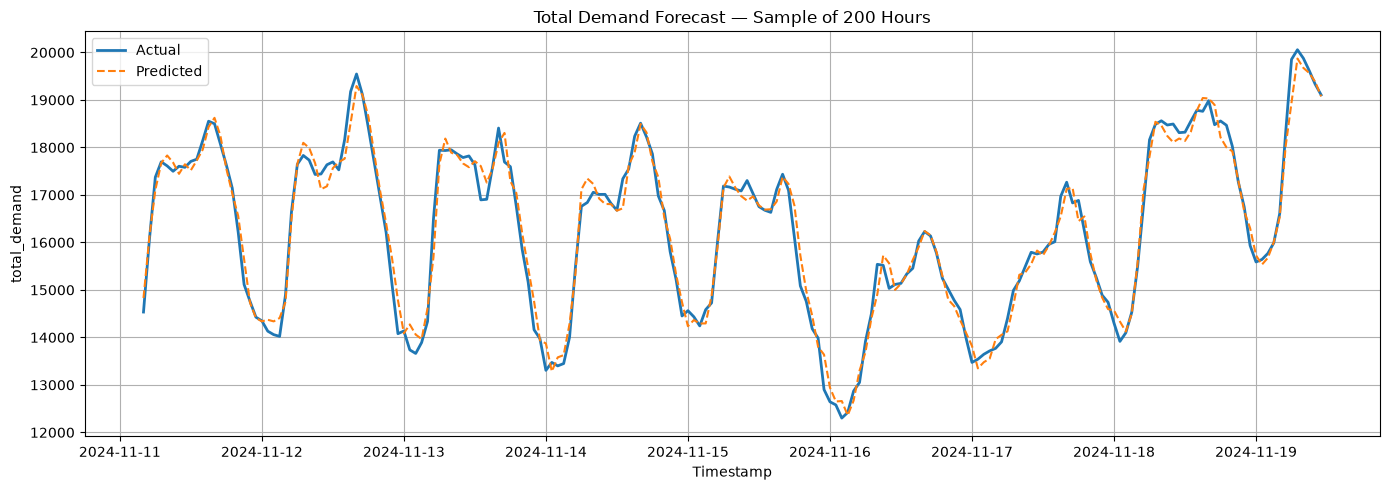

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [41]:
from sklearn import set_config
set_config(display="text")
demand_features = df.columns.drop('total_demand')
run_xgboost_forecast(df, target_column='total_demand', feature_columns=demand_features, model_name='Total Demand Forecast')


In [42]:
#Defining the common function for running the Optuna tuning
def run_optuna_optimization(objective_func, n_trials=30, direction='minimize'): #trials, we can make it maybe 50, its a bit longer
    import optuna
    study = optuna.create_study(direction=direction)
    study.optimize(objective_func, n_trials=n_trials)
    print("Best Score:", study.best_value)
    print("Best Parameters:", study.best_params)
    return study

In [43]:
# Preparing the train and test data again
target_column = 'total_demand'
feature_columns = df.columns.drop('total_demand')

X = df[feature_columns]
y = df[target_column]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [44]:
# defining the xgboost part, so the optuna can run for any model, but we are defining xgboost parameters
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

In [45]:
#Running the optimization
study_xgb = run_optuna_optimization(xgb_objective, n_trials=30)
#running the final model with the best parameters we found
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42)
best_xgb.fit(X_train, y_train)
#Lets see if it worked
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_best = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

d:\coding_study\repo\electricity_demand_forecasting\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-13 20:05:23,405] A new study created in memory with name: no-name-8b3f4e09-f9cd-4d3c-bbbd-b1a16b713cf5
[I 2026-09-13 20:05:24,447] Trial 0 finished with value: 238.75647589820667 and parameters: {'n_estimators': 179, 'max_depth': 6, 'learning_rate': 0.22320176654875365, 'subsample': 0.7898511975126236, 'colsample_bytree': 0.6845913021113419, 'gamma': 2.5555166874928084, 'min_child_weight': 6}. Best is trial 0 with value: 238.75647589820667.
[I 2026-09-13 20:05:39,704] Trial 1 finished with value: 227.47141037939102 and parameters: {'n_estimators': 378, 'max_depth': 13, 'learning_rate': 0.03002635617321687, 'subsample': 0.8142745800946327, 'colsample_bytree': 0.6440819724860545, 'gamma': 2.566302

Best Score: 210.02554820230426
Best Parameters: {'n_estimators': 459, 'max_depth': 7, 'learning_rate': 0.022086983480576444, 'subsample': 0.8688147717673051, 'colsample_bytree': 0.9564860120302265, 'gamma': 4.896497717067335, 'min_child_weight': 1}
MAE: 210.03
R² Score: 0.9925


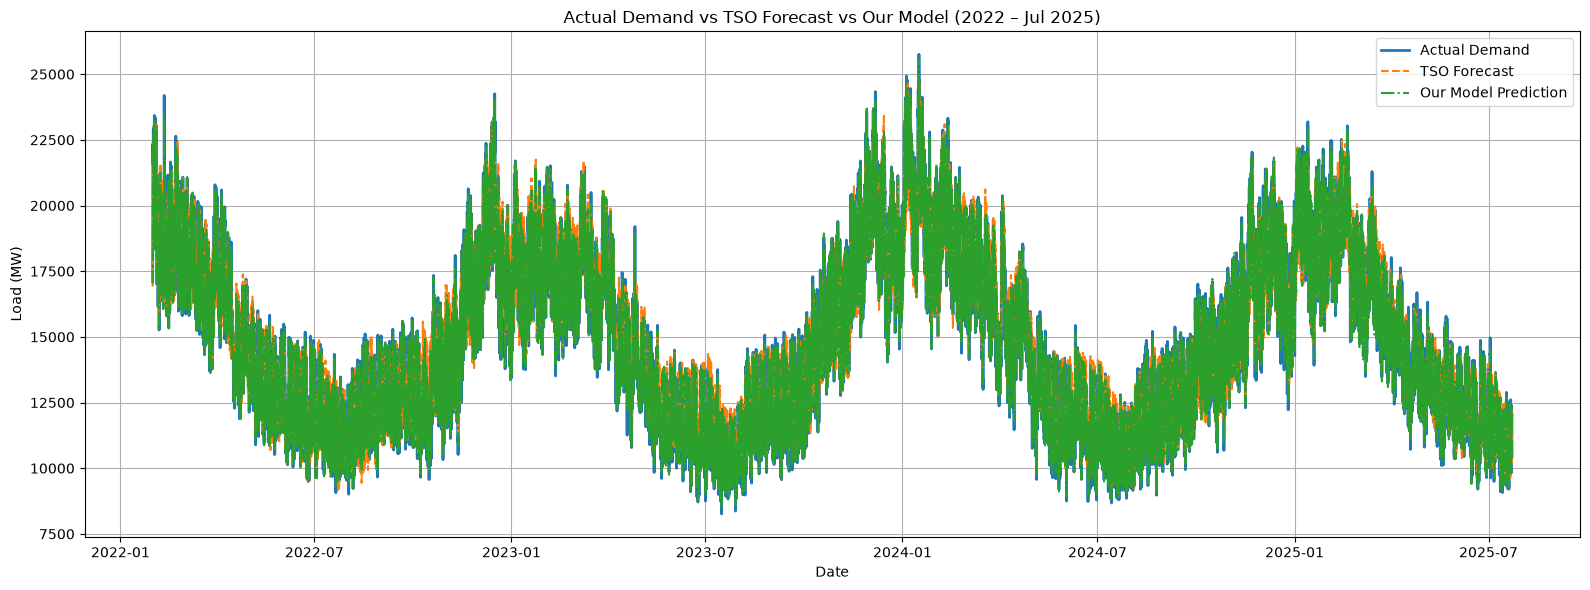

 MAE (TSO vs Actual): 433.05
 MAE (Model vs Actual): 148.40
 R² (TSO vs Actual): 0.9697
 R² (Model vs Actual): 0.9962


In [46]:
X_all = df[feature_columns]
df['our_prediction'] = best_xgb.predict(X_all)

# --- Plot comparison ---
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['total_demand'], label='Actual Demand', linewidth=2)
plt.plot(df.index, df['forecast'], label='TSO Forecast', linestyle='--')
plt.plot(df.index, df['our_prediction'], label='Our Model Prediction', linestyle='-.')
plt.title('Actual Demand vs TSO Forecast vs Our Model (2022 – Jul 2025)')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Metrics over the full dataset ---
mae_tso = mean_absolute_error(df['total_demand'], df['forecast'])
mae_model = mean_absolute_error(df['total_demand'], df['our_prediction'])

r2_tso = r2_score(df['total_demand'], df['forecast'])
r2_model = r2_score(df['total_demand'], df['our_prediction'])

print(f" MAE (TSO vs Actual): {mae_tso:.2f}")
print(f" MAE (Model vs Actual): {mae_model:.2f}")
print(f" R² (TSO vs Actual): {r2_tso:.4f}")
print(f" R² (Model vs Actual): {r2_model:.4f}")

### Monthly Generation and Demand

- Sweden meets this fluctuating demand with a generation mix anchored by its vast hydro‑electric and nuclear fleets, which together account for roughly 80% of annual output and provide the grid’s firm capacity. Reservoir hydro output peaks in spring (snowmelt), run‑of‑river remains fairly stable year‑round, and nuclear delivers a flat baseload. Over the same timeframe, onshore wind has grown from about 8% to 12% of generation, particularly strong during winter, and solar, though still modest at 2–3%, contributes significantly in summer months. Biomass and waste‑to‑energy plants fill in smaller steady chunks, while fossil‑derived gas and coal play only residual roles (below 5%), and pumped storage hydro offers limited but valuable peak‑shifting capability. This evolving mix underscores Sweden’s transition toward higher shares of variable renewables without compromising reliability.

            Biomass  Energy storage  Fossil Brown coal/Lignite  \
datetime                                                         
2022-01-31      0.0             0.0                        0.0   
2022-02-28      0.0             0.0                        0.0   
2022-03-31      0.0             0.0                        0.0   
2022-04-30      0.0             0.0                        0.0   
2022-05-31      0.0             0.0                        0.0   

            Fossil Coal-derived gas  Fossil Gas  Fossil Hard coal  Fossil Oil  \
datetime                                                                        
2022-01-31                      0.0      122.76               0.0         0.0   
2022-02-28                      0.0     1886.73               0.0         0.0   
2022-03-31                      0.0       99.00               0.0         0.0   
2022-04-30                      0.0      164.64               0.0         0.0   
2022-05-31                      0.0      121.08    

<Figure size 1200x600 with 0 Axes>

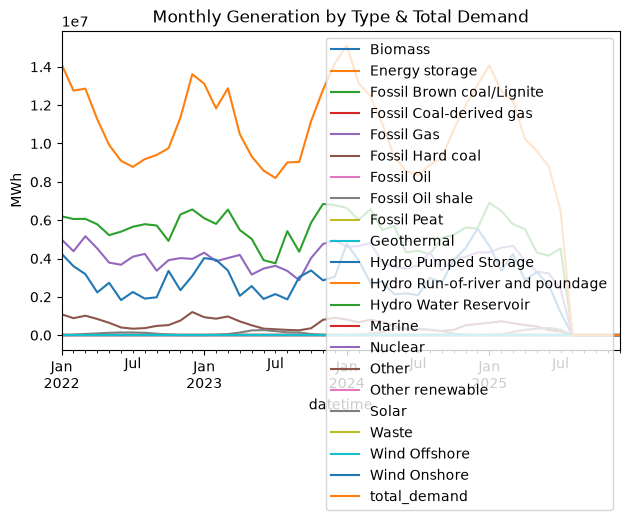

In [49]:

monthly_gen = gen_wide.apply(pd.to_numeric, errors='coerce').resample('ME').sum()


monthly_dem = (
    demand_df[['load']]
    .apply(pd.to_numeric, errors='coerce')
    .resample('ME')
    .sum()
    .rename(columns={'load': 'total_demand'})
)

# 3) Combine into a single DataFrame
monthly_df = pd.concat([monthly_gen, monthly_dem], axis=1)

# 4) Ensure numeric and fill any NaNs
monthly_df = monthly_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# 5) Inspect the first few rows
print(monthly_df.head())

# 6) Quick plot to verify trends
plt.figure(figsize=(12, 6))
monthly_df.plot(title='Monthly Generation by Type & Total Demand', legend=True)
plt.ylabel('MWh')
plt.tight_layout()
plt.show()